## <u>Import Libraries</u>

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision  # special library for computer vision -- datasets, pre-trained CNNs, image transformation utilities
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader, TensorDataset
import torchvision.transforms as transforms  # used to do transformations on the image
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

---
## <u>Image Transformations</u>

Multiclass classification problem. We write a transformation blueprint (like a sklearn pipeline) and apply it to every image. Two steps: scale to `(0,1)`, then normalise to `(-1,1)`.

In [3]:
transformations = transforms.Compose([

    # converts images to pytorch tensors + scales them to (0,1)
    transforms.ToTensor(),

    # mean/std per RGB channel, fixed at 0.5 for this dataset, maps (0,1) -> (-1,1)
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

---
## <u>Load Training and Testing Sets</u>

CIFAR10 is already available as a built-in torchvision dataset -- no manual download/parsing needed, just load it. `train=False` gives the held-out test set.

In [13]:
train_set = CIFAR10("./dataset", train=True, download=True, transform=transformations)
test_set = CIFAR10("./dataset", train=False, download=True, transform=transformations)

print(len(test_set))
print(len(train_set))

Files already downloaded and verified
Files already downloaded and verified
10000
50000


---
## <u>Build TrainLoader and TestLoader</u>

In [5]:
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

---
## <u>Build CNN — architecture notes</u>

**Setup**
- Input image size: `32 x 32 x 3` (height x width x RGB channels)
- PyTorch expects channels-first: `3 x 32 x 32`, not `32 x 32 x 3`
- A "convolutional layer" = convolution + ReLU + max pooling, stacked together (don't confuse "one `Conv2d` call" with "one conv layer" -- the layer is the whole trio)
- Convolution settings used here: kernel size `3x3`, stride `1`, padding `1`
- Max pooling settings used here: kernel size `2x2`, stride `2`, no padding

**Why the numbers change at each stage**
- The output **channel** count after a conv layer has nothing to do with the input's channel count -- it's simply how many filters you told the layer to use (`nn.Conv2d(in, out, ...)` -- `out` = number of filters, a number *you* choose, same as picking hidden layer width for a plain ANN). Each filter automatically spans the entire input depth but produces just one 2D output map; stack `N` filters, get `N` output channels.
- The **spatial size** (32x32) does not shrink from convolution here, because `padding=1` + `kernel=3` is specifically chosen to preserve it: `output = input - kernel + 2*padding + 1 = 32-3+2+1 = 32`.
- **Max pooling is what actually shrinks spatial size** -- it slides a 2x2 window, keeps only the max value in each, cutting height and width in half. It does not touch channel count -- pooling has no filters.
- Channels double (`32 -> 64 -> 128`) while spatial size halves (`32 -> 16 -> 8 -> 4`) at each stage -- a deliberate trade-off: as positional detail shrinks, filter count grows to give the network more room to represent increasingly complex patterns at each coarser scale.

**Dimension flow through this architecture** (see physical notes for the diagram):
```
32x32x3   --conv, 32 filters-->  32x32x32  --maxpool 2x2-->  16x16x32
16x16x32  --conv, 64 filters-->  16x16x64  --maxpool 2x2-->  8x8x64
8x8x64    --conv, 128 filters--> 8x8x128   --maxpool 2x2-->  4x4x128
4x4x128   --flatten--> 2048 values
```

**After the conv stack**
- Flatten the `4x4x128` block into one 1D vector of `2048` values -- `nn.Linear` layers only accept 1D input per sample, same reason the tabular ANN's input layer needed a flat vector.
- One more Linear + ReLU layer after flattening, then into the fully connected (classifier) head.
- 10 classes to predict -> 10 neurons in the output layer (same "output width = number of classes" rule as the DateFruit multiclass ANN).
- Multiclass -> `CrossEntropyLoss` (already includes softmax internally, no need to add it to the output layer) + `Adam` optimizer.

**Dropout placement:** the FC head, not the conv layers -- `nn.Linear(2048, 256)` alone holds ~524K weights, by far the largest concentration of parameters in the network (conv filters are small and shared across the whole image, so they carry far fewer weights each). Overfitting risk tracks with parameter count, so that's where dropout does the most good. `0.3` placed after the first FC layer's ReLU, none after the final output layer.

In [6]:
class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(
            # (in_channels, out_channels, kernel_size, padding)
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # kernel size = 2, stride = 2

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(4 * 4 * 128, 256),  # flattened input, output size chosen by us
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 10)  # 10 predicted classes
        )

    def forward(self, x):
        x_conv = self.conv_layers(x)
        x_flat = x_conv.view(x_conv.size(0), -1)  # flatten
        x_fc = self.fc_layers(x_flat)

        return x_fc

---
## <u>Compile the Model</u>

In [7]:
model = CNN()
loss_func = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

---
## <u>Train the Model</u>

Best-epoch checkpointing on validation loss, same pattern as every prior build.

In [8]:
epochs = 15
train_loss_history = []
val_loss_history = []
best_val_loss = float("inf")

for epoch in range(epochs):

    total_train_loss = 0.0
    model.train()

    for images, labels in train_loader:
        optimizer.zero_grad()
        y_pred_tensor = model(images)
        batch_loss = loss_func(y_pred_tensor, labels)
        batch_loss.backward()
        optimizer.step()

        total_train_loss = total_train_loss + batch_loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)

    total_val_loss = 0.0
    model.eval()

    with torch.no_grad():
        for images, labels in test_loader:
            y_pred_tensor = model(images)
            batch_loss = loss_func(y_pred_tensor, labels)

            total_val_loss = total_val_loss + batch_loss.item()

    avg_val_loss = total_val_loss / len(test_loader)
    val_loss_history.append(avg_val_loss)

    print(f"epoch = {epoch+1}/{epochs} -------> training loss = {avg_train_loss} ---------> validation loss = {avg_val_loss}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_CNN_model.pt")

epoch = 1/15 -------> training loss = 1.4518239569023748 ---------> validation loss = 1.1445971009449456
epoch = 2/15 -------> training loss = 1.04255464840728 ---------> validation loss = 0.9131570010901259
epoch = 3/15 -------> training loss = 0.8491053419649753 ---------> validation loss = 0.8341028776983864
epoch = 4/15 -------> training loss = 0.7268944041960684 ---------> validation loss = 0.7507077688797594
epoch = 5/15 -------> training loss = 0.6441427236017974 ---------> validation loss = 0.7516383680101401
epoch = 6/15 -------> training loss = 0.5617465812836766 ---------> validation loss = 0.713480186681397
epoch = 7/15 -------> training loss = 0.5010604579430407 ---------> validation loss = 0.7324908149604219
epoch = 8/15 -------> training loss = 0.4488492664283194 ---------> validation loss = 0.7211935919599411
epoch = 9/15 -------> training loss = 0.3961737586371124 ---------> validation loss = 0.7468206025541019
epoch = 10/15 -------> training loss = 0.35255184365660336

---
## <u>Plot the Loss Curves</u>

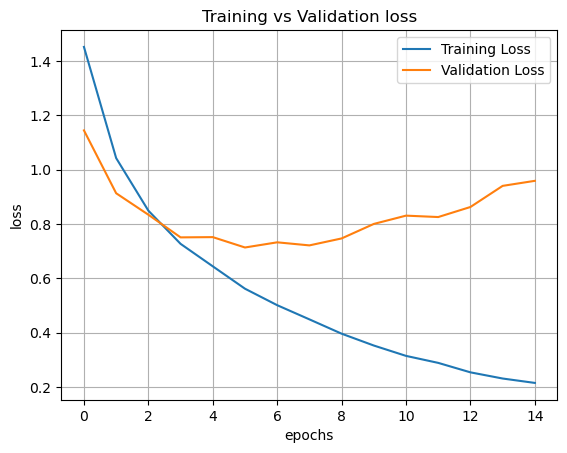

In [9]:
df_loss = pd.DataFrame({
    "Training Loss": train_loss_history,
    "Validation Loss": val_loss_history
})

plt.plot(df_loss["Training Loss"], label="Training Loss")
plt.plot(df_loss["Validation Loss"], label="Validation Loss")

plt.xlabel("epochs")
plt.ylabel("loss")
plt.title("Training vs Validation loss")
plt.grid(True)
plt.legend()
plt.show()

---
## <u>Load Best Checkpoint</u>

In [10]:
model.load_state_dict(torch.load("best_CNN_model.pt", weights_only=True))

<All keys matched successfully>

---
## <u>Evaluate — Training Set</u>

No single `X_train_tensor` exists for image data (too large to hold as one tensor) -- predictions and labels are accumulated batch by batch via `train_loader`, then stitched together with `torch.cat` before computing metrics once on the full set. Only `predicted_classes` (post-`argmax`) vs `labels` are needed here -- accuracy/precision/recall/F1 never require the raw logits, unlike training itself, which needs them for `loss.backward()`.

In [11]:
model.eval()

all_train_preds = []
all_train_labels = []

with torch.no_grad():
    for images, labels in train_loader:
        y_pred_tensor = model(images)  # raw logits, shape (batch_size, 10)
        predicted_classes = torch.argmax(y_pred_tensor, dim=1)

        all_train_preds.append(predicted_classes)
        all_train_labels.append(labels)

# stitch all batches back into one tensor each, covering the full training set
all_train_preds = torch.cat(all_train_preds)
all_train_labels = torch.cat(all_train_labels)

accuracy = accuracy_score(all_train_labels.numpy(), all_train_preds.numpy())
precision = precision_score(all_train_labels.numpy(), all_train_preds.numpy(), average='weighted')
F1_Score = f1_score(all_train_labels.numpy(), all_train_preds.numpy(), average='weighted')
recall = recall_score(all_train_labels.numpy(), all_train_preds.numpy(), average='weighted')

print("Training Accuracy:", accuracy)
print("Training Precision:", precision)
print("Training F1 score:", F1_Score)
print("Training Recall:", recall)

Training Accuracy: 0.85822
Training Precision: 0.8608471137957014
Training F1 score: 0.8577612677783643
Training Recall: 0.85822


---
## <u>Evaluate — Test Set</u>

In [12]:
model.eval()

all_test_preds = []
all_test_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        y_pred_tensor = model(images)  # raw logits, shape (batch_size, 10)
        predicted_classes = torch.argmax(y_pred_tensor, dim=1)

        all_test_preds.append(predicted_classes)
        all_test_labels.append(labels)

# stitch all batches back into one tensor each, covering the full test set
all_test_preds = torch.cat(all_test_preds)
all_test_labels = torch.cat(all_test_labels)

accuracy = accuracy_score(all_test_labels.numpy(), all_test_preds.numpy())
precision = precision_score(all_test_labels.numpy(), all_test_preds.numpy(), average='weighted')
F1_Score = f1_score(all_test_labels.numpy(), all_test_preds.numpy(), average='weighted')
recall = recall_score(all_test_labels.numpy(), all_test_preds.numpy(), average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("F1 score:", F1_Score)
print("Recall:", recall)

Accuracy: 0.7568
Precision: 0.7582499383143866
F1 score: 0.7548369241866171
Recall: 0.7568
